# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [3]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


In [4]:
# Calculate the median and standard deviation for columns with missing values

# for col in df.columns:
#     if col not in ["Id", "Species"]:
#         df[col] = pd.to_numeric(df[col], errors="coerce")

# missing_cols = df.columns[df.isnull().any()].tolist()
# print("Columns with missing values:", missing_cols, "\n")

# report = pd.DataFrame({
#     "median": df[missing_cols].median(skipna=True),
#     "std": df[missing_cols].std(skipna=True)
# })

# report

## Data Preprocessing

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputation = KNNImputer(n_neighbors=5)

    df[feature_cols] = imputation.fit_transform(df[feature_cols])
    
    # ---------- --------------------- ----------
     
    return df, feature_cols 

df, feature_cols = data_preprocessing(df)

In [6]:
missing_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'BranchLength']

df[missing_cols].describe()
# df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,6.319840,2.837040,5.049883,1.684440,16.303440
std,1.009275,0.372434,1.514955,0.694645,1.011012
min,3.000000,1.500000,0.500000,-1.000000,12.700000
25%,5.800000,2.630000,4.500000,1.300000,15.800000
50%,6.300000,2.900000,5.035683,1.700000,16.300000
75%,6.700000,3.040000,5.300000,2.000000,16.700000
max,9.600000,4.000000,9.200000,4.300000,19.700000


## Data Exploration

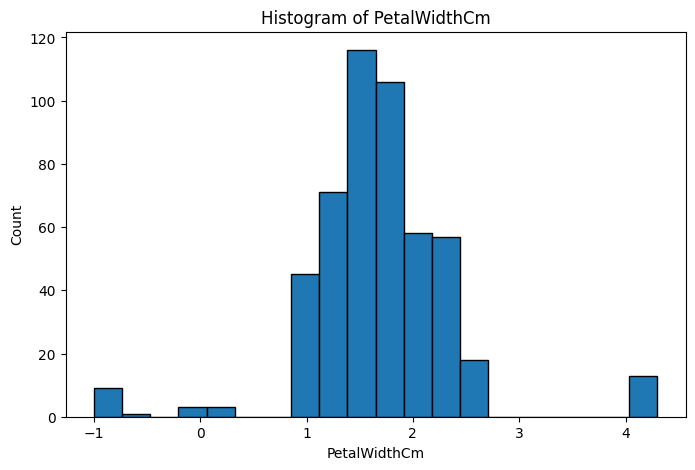

In [7]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration

plt.figure(figsize=(8, 5))
plt.hist(df["PetalWidthCm"], bins=20, edgecolor="black")
plt.title("Histogram of PetalWidthCm")
plt.xlabel("PetalWidthCm")
plt.ylabel("Count")
plt.show()

In [8]:
# List the feature that has the largest positive correlation with "PetalWidthCm"

feature_cols = [c for c in df.columns if c not in ["PetalWidthCm", "Species", "Id"]]

feature_corr = df[feature_cols].corrwith(df["PetalWidthCm"], method="pearson")

positive_corr = feature_corr[feature_corr > 0].sort_values(ascending=False)


best_feature = positive_corr.index[0]
best_corr = positive_corr.iloc[0]
print(f"{best_feature}: {best_corr:.4f}")

print("\nTop5 features:")
print(positive_corr.head(5))



PetalWidthCompactness: 0.9917

Top5 features:
PetalWidthCompactness    0.991670
PetalWidthElongation     0.991551
PetalWidthCurvature      0.991273
PetalWidthMajorAxis      0.991141
PetalWidthSpread         0.991095
dtype: float64


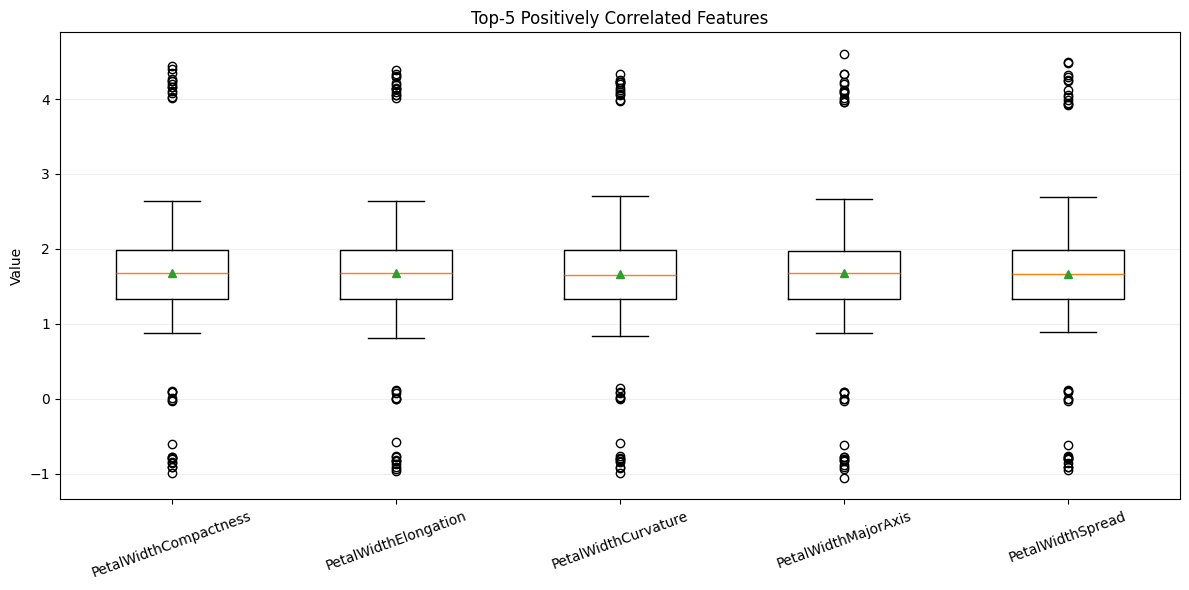

In [9]:
# Boxplot for PetalWidthCm and top-5 positively correlated features

plot_cols = positive_corr.head(5).index.tolist()
plot_df = df[plot_cols]

plt.figure(figsize=(12, 6))
plt.boxplot(
    [df[col].dropna() for col in plot_cols],
    tick_labels=plot_cols,
    showmeans=True
)
plt.title("Top-5 Positively Correlated Features")
plt.ylabel("Value")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## Model Training

### Prepare the data

In [10]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,1.4,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,1.5,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,1.5,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,1.3,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,1.5,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


In [11]:
from sklearn.model_selection import KFold, cross_val_score
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]

cv = KFold(n_splits=5, shuffle=True, random_state=40)

records = []

for lr in learning_rates:
    for reg_lambda in reg_lambdas:
        clf = LinearModel(
            dim=X_train.shape[1],
            is_reg=False,
            loss_fn=logloss,
            act_fn=sigmoid,
            grad_fn=logloss_sigmoid_grad,
            lr=lr,
            reg_type='l2',
            reg_lambda=reg_lambda,
            n_iteration=10000,
            val_ratio=0.2,
            random_state=seed,
            verbose=False,
            plot_curve=False
        )

        scores = cross_val_score(
            estimator=clf,
            X=X_train,
            y=y_train,
            cv=cv,
            scoring='accuracy'
        )

        records.append({
            'learning_rate': lr,
            'reg_lambda': reg_lambda,
            'mean_accuracy': scores.mean()
        })

cv_results = pd.DataFrame(records)

cv_table = cv_results.pivot(
    index='learning_rate',
    columns='reg_lambda',
    values='mean_accuracy'
).reindex(index=learning_rates, columns=reg_lambdas)

print('5-fold CV average accuracy (rows=learning_rate, cols=reg_lambda):')
display(cv_table.round(4))

best_row = cv_results.loc[cv_results['mean_accuracy'].idxmax()]
best_lr = float(best_row['learning_rate'])
best_reg_lambda = float(best_row['reg_lambda'])
best_cv_acc = float(best_row['mean_accuracy'])

print(f'Best hyperparameters -> lr={best_lr}, reg_lambda={best_reg_lambda}, CV accuracy={best_cv_acc:.4f}')

5-fold CV average accuracy (rows=learning_rate, cols=reg_lambda):


reg_lambda,1.0,2.0,4.0,8.0
learning_rate,,,,
0.005,0.7314,0.7286,0.7286,0.7114
0.010,0.7314,0.7257,0.7171,0.7171
0.100,0.7257,0.7229,0.7143,0.7171
0.500,0.7257,0.7057,0.5400,0.4686


Best hyperparameters -> lr=0.01, reg_lambda=1.0, CV accuracy=0.7314


### Train the model!

Top-2 hyperparameter settings from CV:


,learning_rate,reg_lambda,mean_accuracy
0,0.010,1.0,0.731429
1,0.005,1.0,0.731429


50. Training loss: 5.316880802632779, Val loss:5.686784541875727
100. Training loss: 3.874957279313896, Val loss:4.139212635907592
150. Training loss: 2.0327857764970343, Val loss:2.1455741983154804
200. Training loss: 0.7985197730337327, Val loss:0.8096544179526806
250. Training loss: 0.6777587529238083, Val loss:0.6619555357953149
300. Training loss: 0.6720543066736988, Val loss:0.6532132839433348
350. Training loss: 0.6681631961895315, Val loss:0.6499212582779716
400. Training loss: 0.6644135201322294, Val loss:0.6471614235387807
450. Training loss: 0.6607814579539907, Val loss:0.6445452192428119
500. Training loss: 0.6572621142995453, Val loss:0.6420286966274041
550. Training loss: 0.6538509587994548, Val loss:0.6396035776118811
600. Training loss: 0.6505436549557461, Val loss:0.637265580260213
650. Training loss: 0.6473360562653555, Val loss:0.6350110093619344
700. Training loss: 0.6442241994953828, Val loss:0.6328363813194825
750. Training loss: 0.6412042974676385, Val loss:0.630

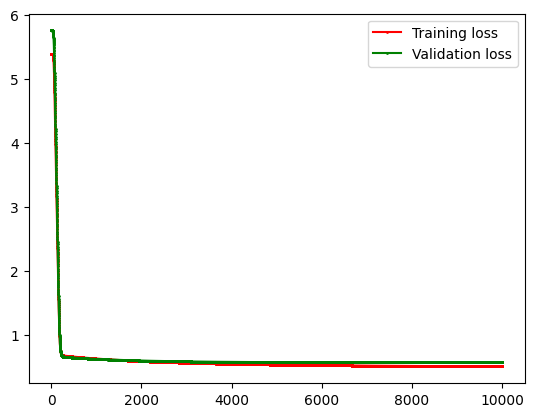

50. Training loss: 5.384999820034422, Val loss:5.756467732512389
100. Training loss: 5.312554652319191, Val loss:5.686793082141314
150. Training loss: 4.773055515464737, Val loss:5.124611224808835
200. Training loss: 3.8563476415459443, Val loss:4.139290581659188
250. Training loss: 2.925369542733359, Val loss:3.1314062992310863
300. Training loss: 2.015481423022667, Val loss:2.1459524908309877
350. Training loss: 1.2242414100669947, Val loss:1.2865643063291459
400. Training loss: 0.795738566528782, Val loss:0.8115501409722053
450. Training loss: 0.6933665427749174, Val loss:0.6864452032060622
500. Training loss: 0.6777505892887413, Val loss:0.6622097696356468
550. Training loss: 0.674174390788723, Val loss:0.6559557547782912
600. Training loss: 0.6720192356049942, Val loss:0.6532478215723456
650. Training loss: 0.6700497874256961, Val loss:0.6514453665964369
700. Training loss: 0.6681282515463126, Val loss:0.6499287568922233
750. Training loss: 0.666239042090474, Val loss:0.6485206700

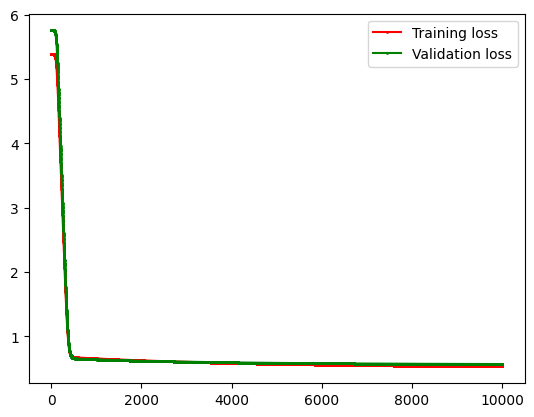

In [12]:
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

if 'cv_results' not in globals():
    raise RuntimeError('Please run the 5-fold CV cell first to create cv_results.')

top2_settings = (
    cv_results
    .sort_values('mean_accuracy', ascending=False)
    .head(2)
    .reset_index(drop=True)
)

print('Top-2 hyperparameter settings from CV:')
display(top2_settings)

top2_models = []

for i, row in top2_settings.iterrows():
    lr = float(row['learning_rate'])
    reg_lambda = float(row['reg_lambda'])
    cv_acc = float(row['mean_accuracy'])

    np.random.seed(seed)
    model_i = LinearModel(
        dim=X_train.shape[1],
        is_reg=False,
        loss_fn=loss_fn,
        act_fn=act_fn,
        grad_fn=grad_fn
    )

    model_i.fit(
        X_train,
        y_train,
        lr=lr,
        n_iteration=10000,
        val_ratio=0.2,
        reg_type='l2',
        reg_lambda=reg_lambda
    )

    top2_models.append({
        'rank': i + 1,
        'lr': lr,
        'reg_lambda': reg_lambda,
        'cv_accuracy': cv_acc,
        'model': model_i
    })

# Keep a default model reference for compatibility with later cells if needed
model = top2_models[0]['model']

## Metrics


Top-1 Setting: lr: 0.01, reg_lambda: 1.0, CV acc: 0.7314
Top-1 Test Evaluation
Accuracy  : 0.7733
Precision : 0.7561
Recall    : 0.8158
F1-score  : 0.7848


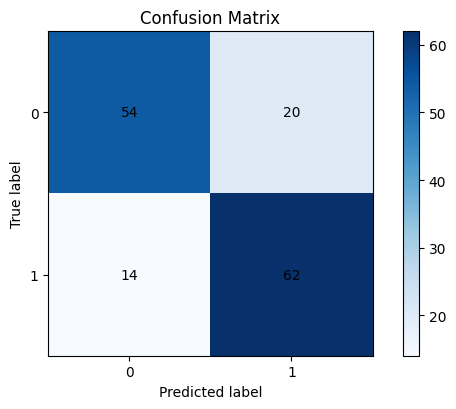


Top-2 Setting: lr: 0.005, reg_lambda: 1.0, CV acc: 0.7314
Top-2 Test Evaluation
Accuracy  : 0.7600
Precision : 0.7326
Recall    : 0.8289
F1-score  : 0.7778


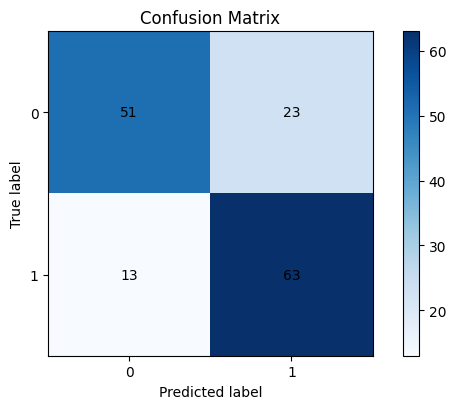

In [13]:
from model.metrics import evaluate_binary_classifier

if 'top2_models' not in globals():
    raise RuntimeError('Please run the training cell for top-2 settings first.')

for item in top2_models:
    rank = item['rank']
    lr = item['lr']
    reg_lambda = item['reg_lambda']
    cv_acc = item['cv_accuracy']

    print(f"\nTop-{rank} Setting: lr: {lr}, reg_lambda: {reg_lambda}, CV acc: {cv_acc:.4f}")
    y_pred = item['model'].predict(X_test)
    evaluate_binary_classifier(y_test, y_pred, title=f"Top-{rank} Test Evaluation")

Model Evaluation
Accuracy  : 0.7733
Precision : 0.7561
Recall    : 0.8158
F1-score  : 0.7848


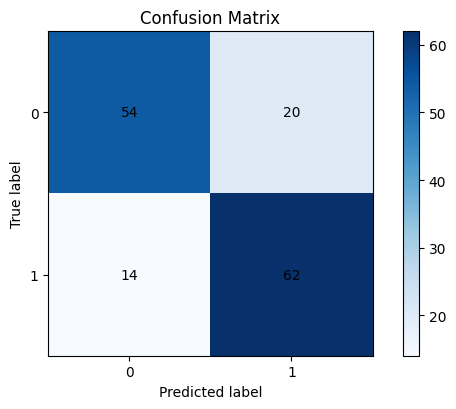

{'Accuracy': 0.7733333333333333,
 'Precision': 0.7560975609756098,
 'Recall': 0.8157894736842105,
 'F1-score': 0.7848101265822784}

In [14]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)

## Question 2: SVM
### (a)

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

mobile_df = pd.read_csv('data/mobile_price.csv')

X_mobile = mobile_df.drop(columns=['price_range'])
y_mobile = mobile_df['price_range']

# trainval = train + val
X_trainval, X_test_mobile, y_trainval, y_test_mobile = train_test_split(
    X_mobile,
    y_mobile,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_mobile
)

# spilt train and val
X_train_mobile, X_val_mobile, y_train_mobile, y_val_mobile = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,
    random_state=42,
    shuffle=True,
    stratify=y_trainval
)

svm_clf = SVC(C=1.0, random_state=42)
svm_clf.fit(X_train_mobile, y_train_mobile)

def evaluate_split(model, X_split, y_split):
    y_pred_split = model.predict(X_split)
    return {
        'Accuracy': accuracy_score(y_split, y_pred_split),
        'F1-score': f1_score(y_split, y_pred_split, average='macro')
    }

svm_results = pd.DataFrame([
    {'Split': 'Train', **evaluate_split(svm_clf, X_train_mobile, y_train_mobile)},
    {'Split': 'Validation', **evaluate_split(svm_clf, X_val_mobile, y_val_mobile)},
    {'Split': 'Test', **evaluate_split(svm_clf, X_test_mobile, y_test_mobile)}
]).set_index('Split')

print('Dataset split sizes:')
print(f'Train: {len(X_train_mobile)}, Validation: {len(X_val_mobile)}, Test: {len(X_test_mobile)}')
print('\nSVM (C=1.0) performance:')
display(svm_results.round(4))

Dataset split sizes:
Train: 1200, Validation: 400, Test: 400

SVM (C=1.0) performance:


,Accuracy,F1-score
Split,,
Train,0.9425,0.9422
Validation,0.9475,0.9472
Test,0.9600,0.9596


### (b)

SVM performance for different C values:


Accuracy                    F1-score                   
Split         Test   Train Validation     Test   Train Validation
C                                                                
0.001       0.8025  0.8075     0.8025   0.8005  0.8057     0.7985
0.010       0.8025  0.8075     0.8025   0.8005  0.8057     0.7985
0.100       0.9100  0.8875     0.8875   0.9096  0.8878     0.8870
1.000       0.9600  0.9425     0.9475   0.9596  0.9422     0.9472
10.000      0.9700  0.9592     0.9575   0.9698  0.9591     0.9575
100.000     0.9775  0.9758     0.9725   0.9774  0.9758     0.9725
1000.000    0.9800  0.9875     0.9750   0.9801  0.9875     0.9750
10000.000   0.9850  0.9950     0.9750   0.9850  0.9950     0.9749

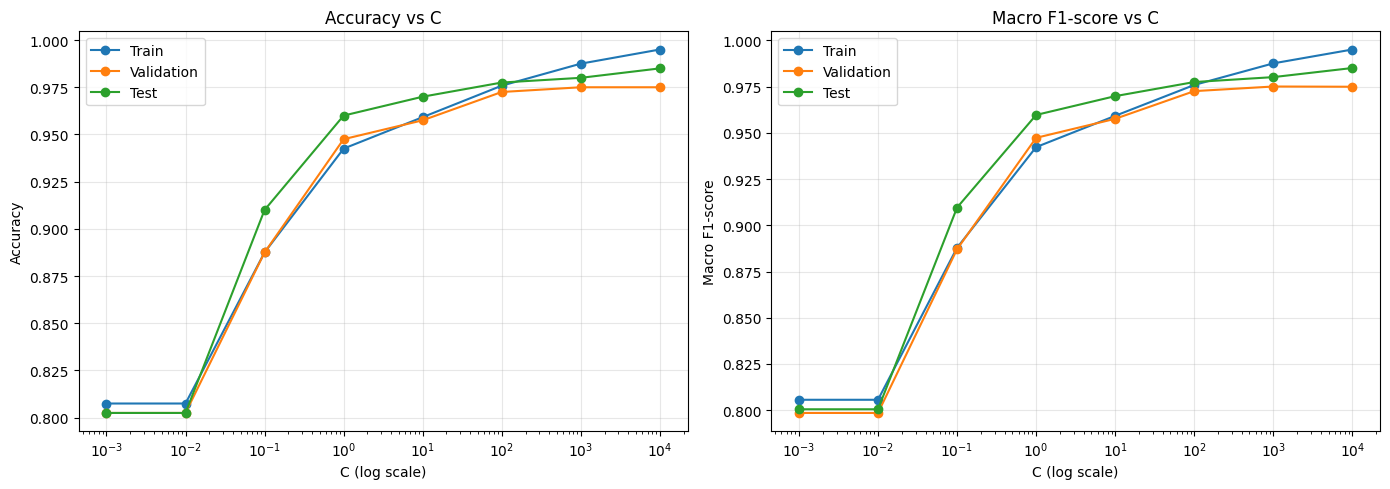

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Make this cell self-contained: recreate splits if needed.
if 'X_train_mobile' not in globals() or 'X_val_mobile' not in globals() or 'X_test_mobile' not in globals():
    mobile_df = pd.read_csv('data/mobile_price.csv')
    X_mobile = mobile_df.drop(columns=['price_range'])
    y_mobile = mobile_df['price_range']

    X_trainval, X_test_mobile, y_trainval, y_test_mobile = train_test_split(
        X_mobile,
        y_mobile,
        test_size=0.2,
        random_state=42,
        shuffle=True,
        stratify=y_mobile
    )

    X_train_mobile, X_val_mobile, y_train_mobile, y_val_mobile = train_test_split(
        X_trainval,
        y_trainval,
        test_size=0.25,
        random_state=42,
        shuffle=True,
        stratify=y_trainval
    )

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

records = []

for c in C_values:
    model_c = SVC(C=c, random_state=42)
    model_c.fit(X_train_mobile, y_train_mobile)

    for split_name, X_split, y_split in [
        ('Train', X_train_mobile, y_train_mobile),
        ('Validation', X_val_mobile, y_val_mobile),
        ('Test', X_test_mobile, y_test_mobile)
    ]:
        y_pred_split = model_c.predict(X_split)
        records.append({
            'C': c,
            'Split': split_name,
            'Accuracy': accuracy_score(y_split, y_pred_split),
            'F1-score': f1_score(y_split, y_pred_split, average='macro')
        })

svm_c_results = pd.DataFrame(records)

print('SVM performance for different C values:')
display(svm_c_results.pivot(index='C', columns='Split', values=['Accuracy', 'F1-score']).round(4))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for split_name in ['Train', 'Validation', 'Test']:
    split_df = svm_c_results[svm_c_results['Split'] == split_name]
    axes[0].plot(split_df['C'], split_df['Accuracy'], marker='o', label=split_name)
    axes[1].plot(split_df['C'], split_df['F1-score'], marker='o', label=split_name)

axes[0].set_xscale('log')
axes[0].set_title('Accuracy vs C')
axes[0].set_xlabel('C (log scale)')
axes[0].set_ylabel('Accuracy')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xscale('log')
axes[1].set_title('Macro F1-score vs C')
axes[1].set_xlabel('C (log scale)')
axes[1].set_ylabel('Macro F1-score')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Question 3: Association Rule Mining

In [3]:
import numpy as np
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

mobile_df = pd.read_csv('data/mobile_price.csv')

# filter
subset_df = mobile_df[mobile_df['price_range'] == 1].copy()
feature_cols_q3 = ['ram', 'int_memory', 'px_width', 'battery_power']

for col in feature_cols_q3:
    col_min = subset_df[col].min()
    col_max = subset_df[col].max()
    col_range = col_max - col_min

    low_high_cut = col_min + 0.3 * col_range
    med_high_cut = col_min + 0.7 * col_range

    subset_df[f'{col}_cat'] = pd.cut(
        subset_df[col],
        bins=[-np.inf, low_high_cut, med_high_cut, np.inf],
        labels=['low', 'medium', 'high'],
        include_lowest=True
    )

transactions = []
for _, row in subset_df.iterrows():
    transaction = [f'{col}_{row[f"{col}_cat"]}' for col in feature_cols_q3]
    transactions.append(transaction)

print('Example transaction records (first 5):')
for t in transactions[:5]:
    print(', '.join(t))

te = TransactionEncoder()
onehot = te.fit(transactions).transform(transactions)
transaction_df = pd.DataFrame(onehot, columns=te.columns_)

frequent_itemsets = fpgrowth(transaction_df, min_support=0.3, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(['support', 'itemsets'], ascending=[False, True]).reset_index(drop=True)
frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(lambda x: ', '.join(sorted(list(x))))

print('\nFrequent patterns (support >= 0.3):')
display(frequent_itemsets)

Example transaction records (first 5):
ram_high, int_memory_low, px_width_low, battery_power_low
ram_medium, int_memory_medium, px_width_medium, battery_power_high
ram_low, int_memory_medium, px_width_high, battery_power_high
ram_medium, int_memory_medium, px_width_low, battery_power_high
ram_medium, int_memory_high, px_width_low, battery_power_medium

Frequent patterns (support >= 0.3):


,support,itemsets
0,0.682,ram_medium
1,0.416,px_width_medium
2,0.414,battery_power_medium
3,0.412,int_memory_medium
4,0.318,"battery_power_medium, ram_medium"
5,0.316,int_memory_low
6,0.308,battery_power_low
7,0.306,"px_width_medium, ram_medium"


In [4]:
### (b)

if 'frequent_itemsets' not in globals() or frequent_itemsets.empty:
    raise RuntimeError('Please run the previous Question 3 cell first to generate frequent_itemsets.')

if isinstance(frequent_itemsets.loc[0, 'itemsets'], str):
    freq_for_rules = fpgrowth(transaction_df, min_support=0.3, use_colnames=True)
else:
    freq_for_rules = frequent_itemsets.copy()

rules = association_rules(freq_for_rules, metric='confidence', min_threshold=0.4)
rules = rules[(rules['support'] >= 0.3) & (rules['confidence'] >= 0.4) & (rules['lift'] >= 0.8)].copy()

if rules.empty:
    print('No association rules satisfy support >= 0.3, confidence >= 0.4, and lift >= 0.8.')
else:
    rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
    rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
    rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
    rules = rules.sort_values(['support', 'confidence', 'lift'], ascending=[False, False, False]).reset_index(drop=True)

    print('Association rules (support >= 0.3, confidence >= 0.4, lift >= 0.8):')
    display(rules.round(4))

Association rules (support >= 0.3, confidence >= 0.4, lift >= 0.8):


,antecedents,consequents,support,confidence,lift
0,battery_power_medium,ram_medium,0.318,0.7681,1.1263
1,ram_medium,battery_power_medium,0.318,0.4663,1.1263
2,px_width_medium,ram_medium,0.306,0.7356,1.0786
3,ram_medium,px_width_medium,0.306,0.4487,1.0786


## Question 4: PCA and K-Means
### (a)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

mobile_df = pd.read_csv('data/mobile_price.csv')

X_all = mobile_df.drop(columns=['price_range']).values
y_all = mobile_df['price_range'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

print('Feature matrix shape:', X_scaled.shape)
print('Mean (should be ~0):', np.round(X_scaled.mean(axis=0)[:5], 4))
print('Std  (should be ~1):', np.round(X_scaled.std(axis=0)[:5], 4))

Feature matrix shape: (2000, 20)
Mean (should be ~0): [ 0. -0. -0.  0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1.]


### (b)

Explained variance ratio: PC1=0.0839, PC2=0.0811
Total explained variance: 0.1650


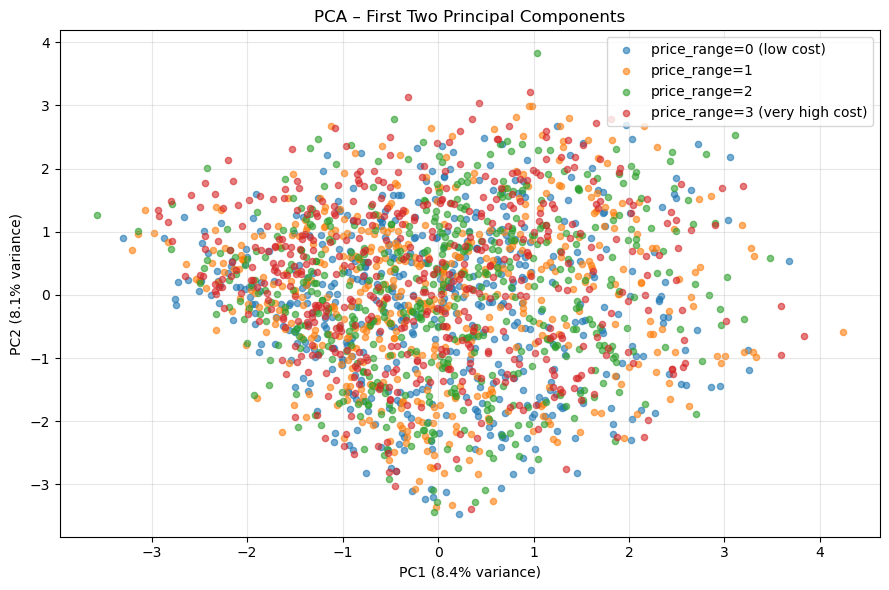

In [6]:
# 4(b): PCA to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.4f}, PC2={pca.explained_variance_ratio_[1]:.4f}')
print(f'Total explained variance: {pca.explained_variance_ratio_.sum():.4f}')

# Scatter plot of first two principal components
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
labels_str = ['price_range=0 (low cost)', 'price_range=1', 'price_range=2', 'price_range=3 (very high cost)']

fig, ax = plt.subplots(figsize=(9, 6))
for cls in range(4):
    mask = y_all == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cls], label=labels_str[cls], alpha=0.6, s=20)

ax.set_title('PCA – First Two Principal Components')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### (c)

K-Means (all features) – Adjusted Rand Score (ARI): 0.0060


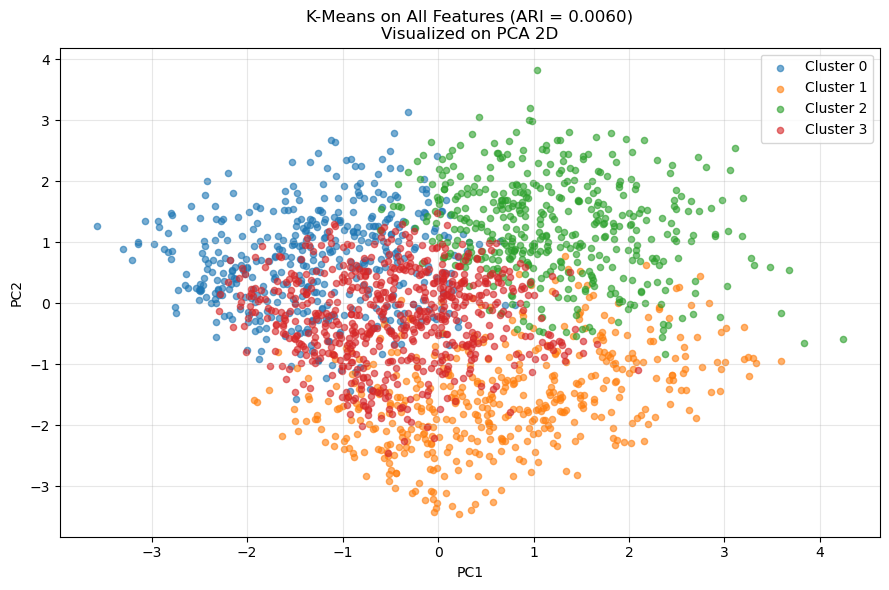

In [7]:
kmeans_full = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_full = kmeans_full.fit_predict(X_scaled)

ari_full = adjusted_rand_score(y_all, labels_full)
print(f'K-Means (all features) – Adjusted Rand Score (ARI): {ari_full:.4f}')

cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(9, 6))
for k in range(4):
    mask = labels_full == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=cluster_colors[k], label=f'Cluster {k}', alpha=0.6, s=20)

ax.set_title(f'K-Means on All Features (ARI = {ari_full:.4f})\nVisualized on PCA 2D')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### (d)

K-Means (PCA 2D) – Adjusted Rand Score (ARI): 0.0017


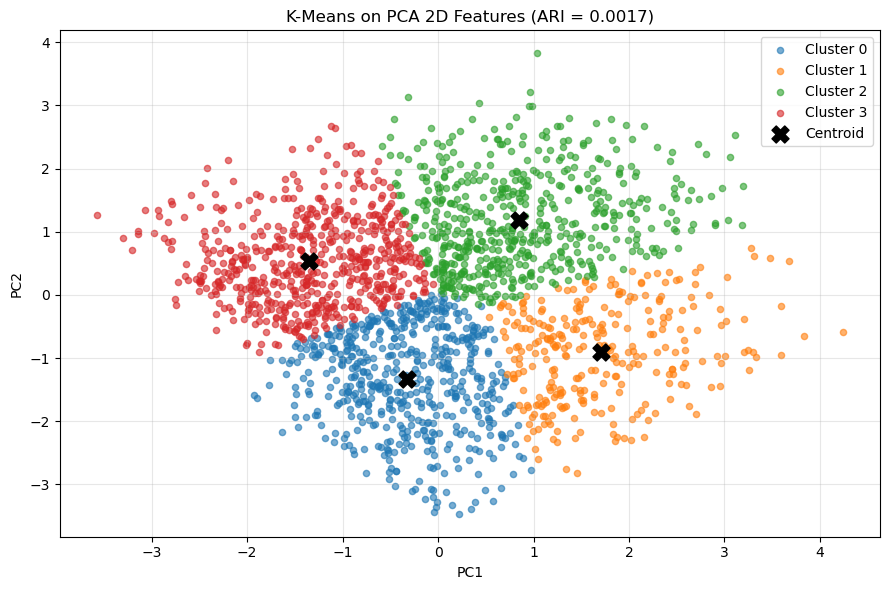


Clustering performance summary:


,Method,ARI
0,K-Means (all features),0.0060
1,K-Means (PCA 2D),0.0017


In [8]:
kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca)

ari_pca = adjusted_rand_score(y_all, labels_pca)
print(f'K-Means (PCA 2D) – Adjusted Rand Score (ARI): {ari_pca:.4f}')

fig, ax = plt.subplots(figsize=(9, 6))
for k in range(4):
    mask = labels_pca == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=cluster_colors[k], label=f'Cluster {k}', alpha=0.6, s=20)

# Plot cluster centroids
ax.scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1],
           c='black', marker='X', s=150, zorder=5, label='Centroid')

ax.set_title(f'K-Means on PCA 2D Features (ARI = {ari_pca:.4f})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Method': ['K-Means (all features)', 'K-Means (PCA 2D)'],
    'ARI': [round(ari_full, 4), round(ari_pca, 4)]
})
print('\nClustering performance summary:')
display(summary)

## Question 5: Enhancing K-Means with Association Rule Mining

**Core idea**
Use association rules to build class-aware rule-score features, then run K-Means on the augmented feature space.

- Baseline: K-Means on standardized numeric features
- Improved: K-Means on `[standardized features + beta * rule-score features]`

**Why this should improve**
- Original K-Means only uses Euclidean distance in raw feature space.
- ARM captures higher-order co-occurrence patterns among discretized features.
- Rules with consequents `price_range = c` provide soft class evidence, which becomes additional dimensions guiding clustering.

**Inspiration / references**
- Association-rule guided K-Means initialization/optimization literature
- Semi-supervised constrained clustering (must-link / cannot-link idea)
- Practical observation from this dataset: single-feature distances are weak, but feature-combination patterns are informative

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.optimize import linear_sum_assignment
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# ----- Data -----
mobile_df = pd.read_csv('data/mobile_price.csv')
feature_names = mobile_df.drop(columns=['price_range']).columns.tolist()
X = mobile_df[feature_names].values
y = mobile_df['price_range'].values.astype(int)

# ----- Baseline feature space -----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----- Build transactions with discretized feature tokens + label token -----
# Use 3:4:3 split by range for each feature.
def build_transactions_with_label(df, feature_cols):
    transactions = []
    for _, row in df.iterrows():
        items = []
        for col in feature_cols:
            cmin = df[col].min()
            crange = df[col].max() - cmin
            low_cut = cmin + 0.3 * crange
            mid_cut = cmin + 0.7 * crange
            v = row[col]
            if v <= low_cut:
                level = 'low'
            elif v <= mid_cut:
                level = 'mid'
            else:
                level = 'high'
            items.append(f'{col}_{level}')
        items.append(f'label_{int(row["price_range"])}')
        transactions.append(items)
    return transactions

transactions = build_transactions_with_label(mobile_df, feature_names)
te = TransactionEncoder()
X_tr = te.fit(transactions).transform(transactions)
trx_df = pd.DataFrame(X_tr, columns=te.columns_)

# ----- Mine class-targeted rules -----
freq = fpgrowth(trx_df, min_support=0.03, use_colnames=True)
rules = association_rules(freq, metric='confidence', min_threshold=0.35)

# Keep rules whose consequent is exactly one class label token
label_tokens = {f'label_{k}' for k in sorted(np.unique(y))}

def consequent_is_single_label(cons):
    return len(cons) == 1 and next(iter(cons)) in label_tokens

rules_cls = rules[rules['consequents'].apply(consequent_is_single_label)].copy()
rules_cls['target'] = rules_cls['consequents'].apply(lambda s: int(next(iter(s)).split('_')[1]))
rules_cls['rule_score'] = rules_cls['confidence'] * rules_cls['lift']

# Use top-k high-quality rules per class to reduce noise
top_k = 25
rules_top = (
    rules_cls.sort_values(['target', 'rule_score'], ascending=[True, False])
             .groupby('target', group_keys=False)
             .head(top_k)
             .reset_index(drop=True)
)

print('Rules kept per class:')
print(rules_top.groupby('target').size())
print(f'Total selected rules: {len(rules_top)}')

# ----- Build rule-score embedding (4 dimensions, one per class) -----
# score_c(x) = sum(rule_score) for rules predicting class c whose antecedent is satisfied by x
item_sets = [set(t) for t in transactions]
n = len(item_sets)
num_classes = len(np.unique(y))
rule_embed = np.zeros((n, num_classes), dtype=float)

for idx, r in rules_top.iterrows():
    c = int(r['target'])
    ant = set(r['antecedents'])
    s = float(r['rule_score'])
    for i, items in enumerate(item_sets):
        if ant.issubset(items):
            rule_embed[i, c] += s

# Standardize rule embedding then concatenate
rule_embed = StandardScaler().fit_transform(rule_embed)

# beta controls how strongly ARM embedding influences clustering
beta = 3.0
X_enhanced = np.hstack([X_scaled, beta * rule_embed])

print('X_scaled shape:', X_scaled.shape)
print('Rule embedding shape:', rule_embed.shape)
print('X_enhanced shape:', X_enhanced.shape)

Rules kept per class:
target
0    25
1    25
2    25
3    25
dtype: int64
Total selected rules: 100
X_scaled shape: (2000, 20)
Rule embedding shape: (2000, 4)
X_enhanced shape: (2000, 24)


Baseline K-Means (per seed):


,Accuracy,Precision,Recall,F1
seed,,,,
0,0.2945,0.2940,0.2945,0.2926
10,0.2955,0.2953,0.2955,0.2936
42,0.2970,0.2966,0.2970,0.2950
100,0.2955,0.2950,0.2955,0.2935
999,0.2985,0.2984,0.2985,0.2956



ARSE-KMeans (per seed):


,Accuracy,Precision,Recall,F1
seed,,,,
0,0.4795,0.7187,0.4795,0.4851
10,0.4795,0.7187,0.4795,0.4851
42,0.4795,0.7187,0.4795,0.4851
100,0.4795,0.7187,0.4795,0.4851
999,0.4795,0.7187,0.4795,0.4851



Average metrics over required seeds:


,Accuracy,Precision,Recall,F1
Baseline K-Means,0.2962,0.2959,0.2962,0.2941
ARSE-KMeans,0.4795,0.7187,0.4795,0.4851



Absolute improvement (ARSE - Baseline):


,Accuracy,Precision,Recall,F1
Delta,0.1833,0.4229,0.1833,0.191


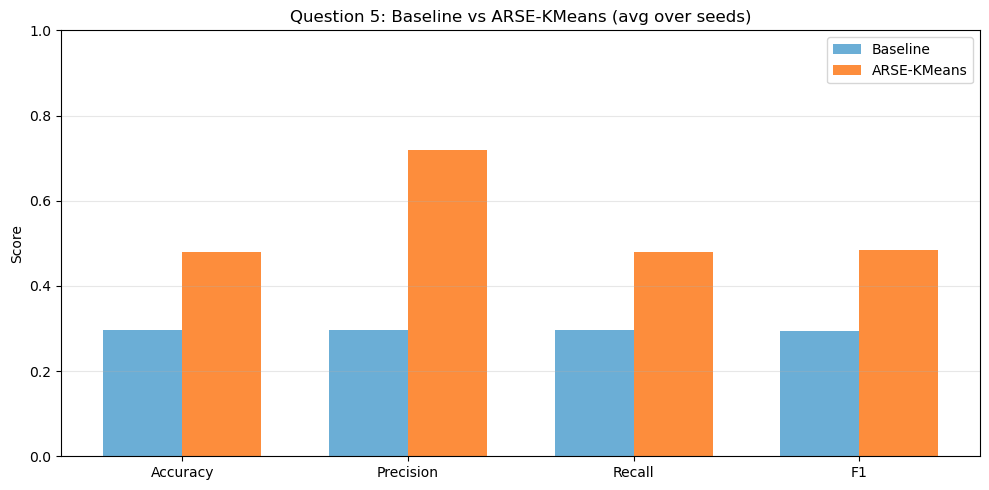

In [ ]:
# ----- Evaluation utilities -----
def map_cluster_to_label(y_true, y_cluster, n_clusters=4):
    cost = np.zeros((n_clusters, n_clusters), dtype=int)
    for i in range(n_clusters):
        for j in range(n_clusters):
            cost[i, j] = np.sum((y_cluster == i) & (y_true == j))
    r, c = linear_sum_assignment(-cost)
    mapping = {ri: ci for ri, ci in zip(r, c)}
    return np.array([mapping[k] for k in y_cluster])

def eval_clustering(y_true, y_cluster):
    y_map = map_cluster_to_label(y_true, y_cluster, n_clusters=4)
    return {
        'Accuracy': accuracy_score(y_true, y_map),
        'Precision': precision_score(y_true, y_map, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_map, average='macro', zero_division=0),
        'F1': f1_score(y_true, y_map, average='macro', zero_division=0)
    }

# ----- Compare baseline vs improved with required seeds -----
seeds = [0, 10, 42, 100, 999]

rows_base = []
rows_impr = []
for s in seeds:
    km_base = KMeans(n_clusters=4, random_state=s, n_init=10)
    pred_base = km_base.fit_predict(X_scaled)
    rows_base.append({'seed': s, **eval_clustering(y, pred_base)})

    km_impr = KMeans(n_clusters=4, random_state=s, n_init=10)
    pred_impr = km_impr.fit_predict(X_enhanced)
    rows_impr.append({'seed': s, **eval_clustering(y, pred_impr)})

base_df = pd.DataFrame(rows_base).set_index('seed')
impr_df = pd.DataFrame(rows_impr).set_index('seed')

print('Baseline K-Means (per seed):')
display(base_df.round(4))

print('\nOurs-KMeans (per seed):')
display(impr_df.round(4))

avg_cmp = pd.DataFrame({
    'Baseline K-Means': base_df.mean(),
    'Ours-KMeans': impr_df.mean()
}).T

improve = (avg_cmp.loc['Ours-KMeans'] - avg_cmp.loc['Baseline K-Means'])

print('\nAverage metrics over required seeds:')
display(avg_cmp.round(4))

print('\nAbsolute improvement (Ours - Baseline):')
display(improve.to_frame('Delta').T.round(4))

# ----- Visualization -----
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, avg_cmp.loc['Baseline K-Means', metrics], w, label='Baseline', color='#6baed6')
ax.bar(x + w/2, avg_cmp.loc['Ours-KMeans', metrics], w, label='Ours-KMeans', color='#fd8d3c')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Question 5: Baseline vs Ours-KMeans (avg over seeds)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()